#  Notebook 3 - CREDITRUST SCORING 

## 1) Introduction

Dans ce notebook, nous allons mettre en place l'ensemble des étapes de Machine Learning nécessaires au projet CrediTrust Scoring.
A partir du fichier loan_data.csv, nous allons explorer les données pour faire émerger les facteurs de risque bancaire, préparer ces données pour la modélisation, entraîner plusieurs modèles de classification, puis sélectionner et interpréter le modèle le plus pertinent pour un contexte métier de scoring de crédit.

### Contexte métier

CrediTrust est un établissement de crédit qui souhaite s'appuyer sur un modèle prédictif pour évaluer le risque associé à une demande de prêt. L'objectif est de prédire si un dossier sera accordé (Y) ou refusé (N), à partir des caractéristiques du demandeur (revenus, historique de crédit, situation familiale, etc.).

Dans ce contexte, toutes les erreurs de prédiction n'ont pas le même coût. Accorder un prêt à un profil réellement à risque (un Faux Négatif, si l'on considère le refus comme la classe positive) représente une perte financière potentielle bien plus grave pour la banque qu'un refus par excès de prudence (Faux Positif). L'évaluation de nos modèles devra donc prioriser la réduction des Faux Négatifs, plutôt que la seule accuracy globale.

### Remarques sur les unités monétaires

Le dataset ne précise pas l'unité monétaire des variables ApplicantIncome, CoapplicantIncome et LoanAmount. Les valeurs sont vraisemblablement exprimées en milliers, sans certitude sur la devise d'origine. Cette incertitude n'affecte pas l'analyse du risque de crédit, qui repose sur les distributions et corrélations relatives plutôt que sur les montants absolus.

### Objectifs

À la fin de ce notebook, nous serons capables de :

- Réaliser une analyse exploratoire poussée pour identifier les facteurs de risque bancaire.
- Appliquer un prétraitement complet des données (valeurs manquantes, encodage, scaling) sans fuite de données (data leakage).
- Entraîner plusieurs modèles de classification.
- Évaluer ces modèles avec une grille de lecture orientée métier (priorité aux Faux Négatifs).
- Sélectionner le modèle optimal et interpréter les variables les plus influentes (coefficients / feature importances).

## 2) Exploration des Données (EDA)

### 2.1 Extraction des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from sklearn import metrics

In [2]:
df = pd.read_csv("loan_data.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 2.2 Dimensions et types

In [4]:
# Affichage des dimensions
df.shape

(981, 13)

In [5]:
# Affichage des types de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


### 2.3 Statistiques descriptives — numériques et catégorielles

- Données numériques (int64/float64) — 5 colonnes

ApplicantIncome 
CoapplicantIncome 
LoanAmount 
Loan_Amount_Term 
Credit_History 

- Données non numériques (object/texte) — 8 colonnes

Loan_ID
Gender
Married
Dependents
Education
Self_Employed
Property_Area
Loan_Status

In [6]:
# Examen des statistiques descriptives des variables numériques
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [7]:
# Examen des statistiques descriptives des variables catégorielles
df.describe(include=['O'])

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,981,957,978,956,981,926,981,614
unique,981,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,775,631,545,763,807,349,422


### 2.4 Visualisation des données

#### A) Distribution des variables numériques (histplot)

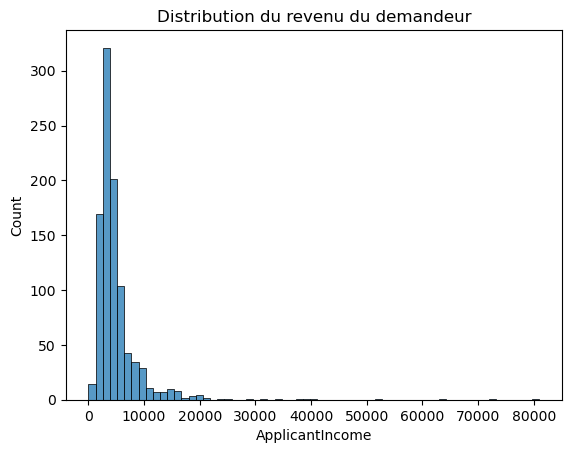

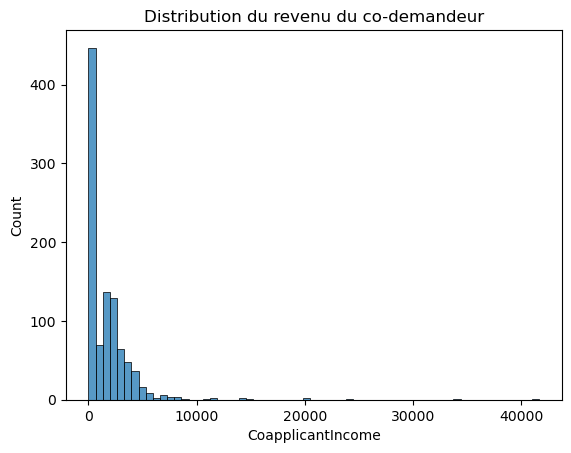

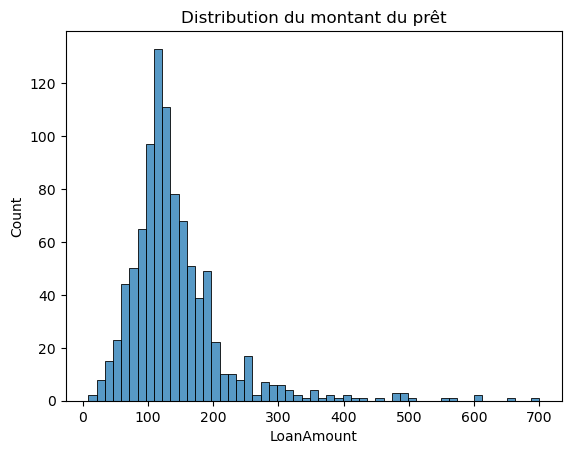

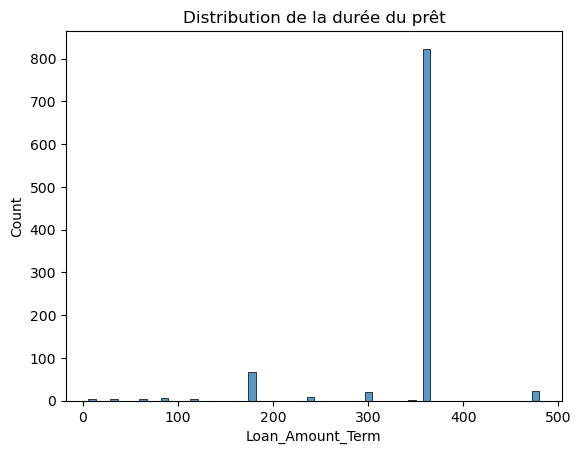

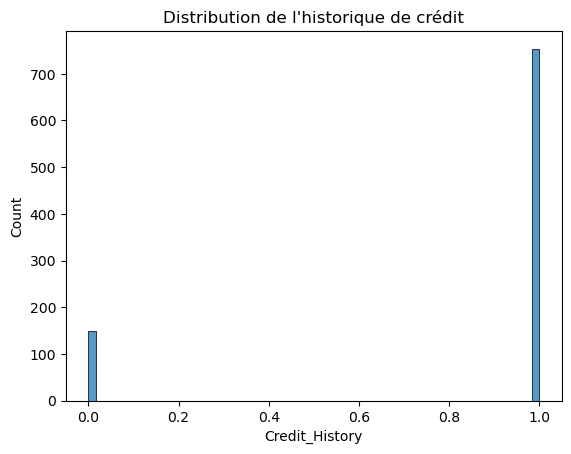

In [8]:
# Distribution des valeurs numériques
sns.histplot(df["ApplicantIncome"])
plt.title("Distribution du revenu du demandeur")
plt.show()

sns.histplot(df["CoapplicantIncome"])
plt.title("Distribution du revenu du co-demandeur")
plt.show()

sns.histplot(df["LoanAmount"])
plt.title("Distribution du montant du prêt")
plt.show()

sns.histplot(df["Loan_Amount_Term"])
plt.title("Distribution de la durée du prêt")
plt.show()

sns.histplot(df["Credit_History"])
plt.title("Distribution de l'historique de crédit")
plt.show()

#Interprétation des graphiques :

- Revenu du demandeur (ApplicantIncome)
La plupart des gens ont un revenu assez bas, entre 0 et 10 000. Quelques personnes gagnent beaucoup plus, jusqu'à 80 000, mais elles sont très rares. Ça fait une courbe avec une longue queue vers la droite.

- Revenu du co-demandeur (CoapplicantIncome)
Beaucoup de dossiers ont 0 comme revenu de co-demandeur. Ça veut dire qu'il n'y a pas de co-emprunteur dans ces cas-là. Les autres dossiers ont un revenu de co-demandeur, mais ça reste plutôt bas, avec quelques cas plus élevés et rares.

- Montant du prêt (LoanAmount)
La plupart des prêts demandés tournent autour de 100 à 150. Quelques prêts sont beaucoup plus gros, jusqu'à 700, mais c'est rare.

- Durée du prêt (Loan_Amount_Term)
Presques tous les prêts ont la même durée (360 mois, soit 30 ans probablement). On a donc une variable presque constante qui ne nous permettra pas de distinguer les profils à risque des autres.

- Historique de crédit (Credit_History)
La grande majorité des demandeurs (environ 750/902) ont un bon historique de crédit (1). Une minorité (environ 150) a un mauvais historique (0).

#Conclusion 

- ApplicantIncome, CoapplicantIncome et LoanAmount présentent toutes les trois une distribution étalée à droite, avec une majorité de petites valeurs et quelques valeurs extrêmes qui devront être traitées avant la modélisation.
- Loan_Amount_Term varie très peu (plus de 80% des dossiers partagent la même durée) : elle sera probablement peu informative pour distinguer les profils.
- Credit_History est répartie entre deux catégories nettement déséquilibrées (majorité de bons historiques).

#### B) Corrélations (heatmap)

<Axes: >

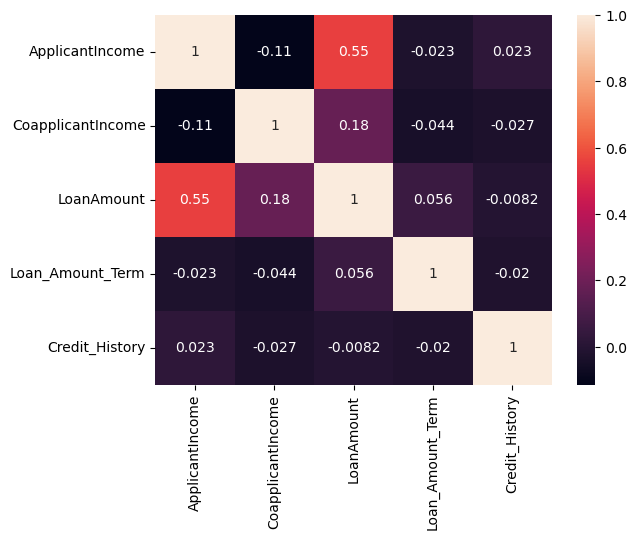

In [9]:
sns.heatmap(df.corr(method='pearson', min_periods=1, numeric_only=True), annot=True)

- Corrélation la plus forte : ApplicantIncome et LoanAmount sont liés avec une corrélation de 0.57. Ça veut dire que plus le revenu du demandeur est élevé, plus le montant du prêt demandé a tendance à être élevé aussi. 

- Corrélation la plus faible : CoapplicantIncome et LoanAmount sont liés avec 0.19.

- Tout le reste est proche de 0 : Loan_Amount_Term et Credit_History n'ont quasiment aucun lien avec les autres variables numériques (toutes leurs corrélations sont proches de 0, entre -0.06 et 0.04). 

#### C) Identification des valeurs manquantes

In [10]:
# Vérifier les valeurs manquantes
df.isnull().sum()

Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64

#### D) Gestion des valeurs aberrantes

<Axes: ylabel='ApplicantIncome'>

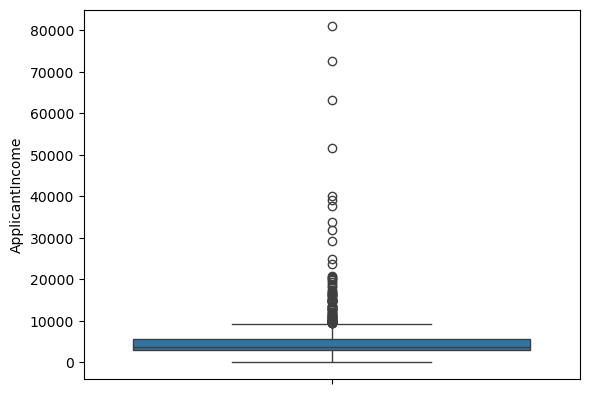

In [11]:
# Boxplot de ApplicantIncome (revenu du demandeur)
sns.boxplot(df["ApplicantIncome"])

<Axes: ylabel='CoapplicantIncome'>

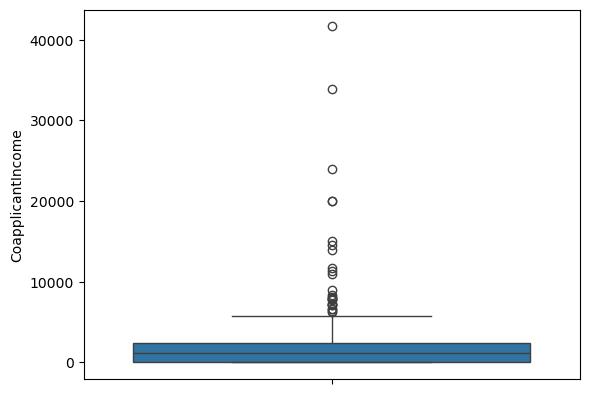

In [12]:
# Boxplot de CoapplicantIncome (revenu du co-demandeur)
sns.boxplot(df["CoapplicantIncome"])

<Axes: ylabel='LoanAmount'>

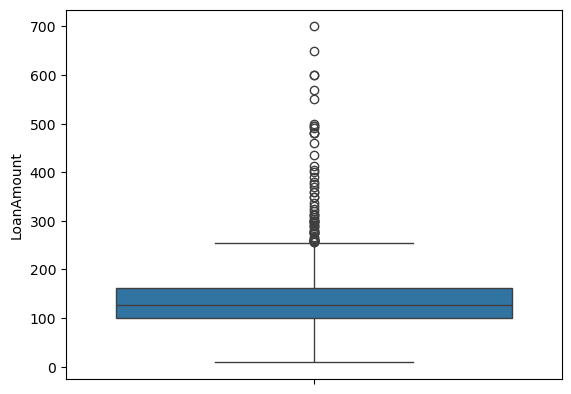

In [13]:
# Boxplot de LoanAmount (montant du prêt)
sns.boxplot(df["LoanAmount"])

Analyse des Boxplot 

- ApplicantIncome (revenu du demandeur)
La boîte est tassée tout en bas, entre 0 et environ 10 000. C'est là que se trouve la majorité des demandeurs. Au-dessus, de nombreux outliers s'étalent progressivement jusqu'à plus de 80 000, avec quelques cas isolés tout en haut. Ces valeurs hautes ne semblent pas être des erreurs de saisie car elles sont nombreuses et progressives. Il s'agirait donc vraisemblablement de vrais profils à revenus élevés.

- CoapplicantIncome (revenu du co-demandeur)
La boîte est très basse et tassée près de 0, cohérent avec le fait que beaucoup de dossiers n'ont pas de co-demandeur. Au-dessus, plusieurs outliers s'étalent de 10 000 jusqu'à plus de 40 000, avec un point isolé tout en haut. La majorité des co-demandeurs ont donc un revenu faible ou nul, mais quelques-uns apportent un revenu bien plus élevé que la norme.

- LoanAmount (montant du prêt)
La boîte est plus resserrée que les deux précédentes, entre 100 et 160 environ. Les outliers commencent au-dessus de 250 et montent jusqu'à 700, avec de nombreux points entre 250 et 500. La plupart des prêts demandés sont donc d'un montant modéré, mais un nombre non négligeable de dossiers demandent des montants bien plus élevés.

### 2.5 Facteurs de risque

Isolement des lignes avec Loan_Staues/target connues

Sur les 981 lignes du dataset, 367 n'ont pas de valeur dans Loan_Status (colonne vide). On ne peut pas les utiliser pour étudier le lien entre les variables et la décision d'octroi de prêt, puisqu'on ne connaît justement pas cette décision pour ces lignes.
On les met donc de côté, et on garde uniquement les 614 lignes où Loan_Status est renseigné.

In [14]:
# Isoler les lignes avec Loan_Status (target)- valeurs manquantes (nécessaire avant les croisements)
df_model = df[df["Loan_Status"].notna()].copy()
df_model.shape  

(614, 13)

#### A) Repartition globale de la cible/Targuet Loan_Status

In [15]:
df_model["Loan_Status"].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

Sur les 614 dossiers : 68.7% de Y (accepté), 31.3% de N (refusé).

#### B) Taux d'accord/refus pour chaque variable catégorielle

In [16]:
for col in ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Dependents"]:
    print(col, "\n", df_model.groupby(col)["Loan_Status"].value_counts(normalize=True), "\n")

Gender 
 Gender  Loan_Status
Female  Y              0.669643
        N              0.330357
Male    Y              0.693252
        N              0.306748
Name: proportion, dtype: float64 

Married 
 Married  Loan_Status
No       Y              0.629108
         N              0.370892
Yes      Y              0.716080
         N              0.283920
Name: proportion, dtype: float64 

Education 
 Education     Loan_Status
Graduate      Y              0.708333
              N              0.291667
Not Graduate  Y              0.611940
              N              0.388060
Name: proportion, dtype: float64 

Self_Employed 
 Self_Employed  Loan_Status
No             Y              0.686000
               N              0.314000
Yes            Y              0.682927
               N              0.317073
Name: proportion, dtype: float64 

Property_Area 
 Property_Area  Loan_Status
Rural          Y              0.614525
               N              0.385475
Semiurban      Y              

- Gender : 66.9% de Y pour Female, 69.3% pour Male. Écart de 2.4 points, proche du taux global (68.7%). => Le genre ne semble quasiment pas influencer la décision.

- Married : 62.9% de Y pour "No", 71.6% pour "Yes". Écart de 8.7 points. => Etre marié semble être associé à un meilleur taux d'acceptation.

- Education : 70.8% de Y pour "Graduate", 61.2% pour "Not Graduate". Écart de 9.6 points. => Avoir un diplôme semble associé à un meilleur taux d'acceptation.

- Self_Employed : 68.6% de Y pour "No", 68.3% pour "Yes". Écart de 0.3 point. => Le statut d'indépendant ne semble avoir aucun effet.

- Property_Area : le plus grand écart parmi les variables catégorielles. Semiurban a le meilleur taux (76.8%), Urban en position intermédiaire (65.8%), Rural nettement en retrait (61.5%). Ecart de 15.3 points entre Semiurban et Rural. => La zone géographique semble avoir un effet important sur la décision d'octroi.

- Dependents : taux assez proches pour la majorité des personnes à charge (64.7% à 75.2%), sauf "2" qui ressort un peu au-dessus. Aucune tendance claire ne se dégage.

Classement provisoire par écart au taux global (68.7%) :

Property_Area (15.3 points)
Education (9.6 points)
Married (8.7 points)
Dependents (effet modéré)
Gender (2.4 points — quasi neutre)
Self_Employed (0.3 point — neutre)

#### C) Croisement Historique de crédit vs Décision

In [17]:
pd.crosstab(df_model["Credit_History"], df_model["Loan_Status"], normalize="index") * 100

Loan_Status,N,Y
Credit_History,,
0.0,92.134831,7.865169
1.0,20.421053,79.578947


Quand Credit_History = 0 (mauvais historique) : seulement 7.9% d'acceptation, soit plus de 92% de refus.
Quand Credit_History = 1 (bon historique) : 79.6% d'acceptation, soit presque 4 fois plus de chances d'être accepté.

Écart de 71.7 points. C'est de très loin l'écart le plus fort de toutes les variables. Credit_History est donc le facteur de risque numéro 1 dans ce dataset.

#### D) Variables numériques vs décision

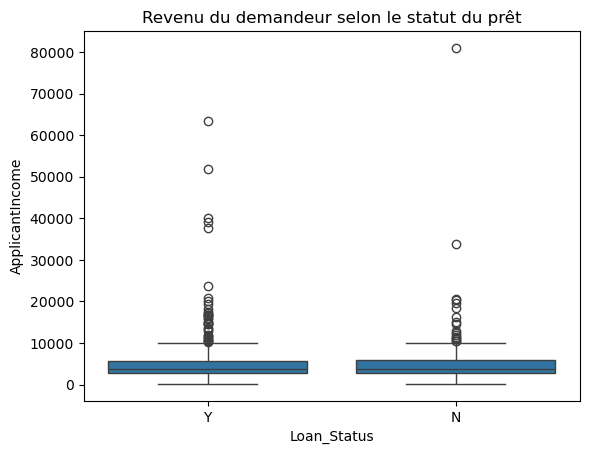

In [18]:
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df_model)
plt.title("Revenu du demandeur selon le statut du prêt")
plt.show()

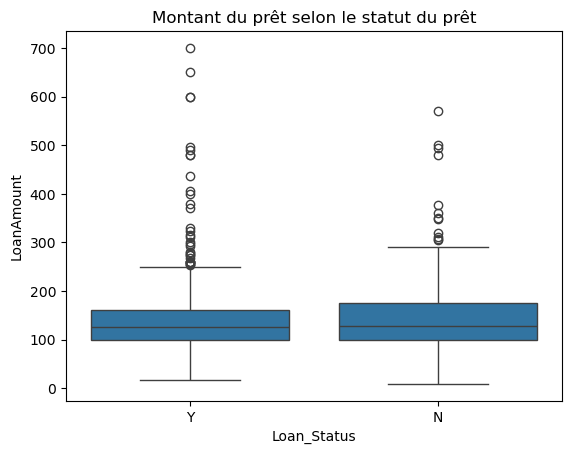

In [19]:
sns.boxplot(x="Loan_Status", y="LoanAmount", data=df_model)
plt.title("Montant du prêt selon le statut du prêt")
plt.show()

Contrairement à ce qu'on aurait pu attendre, ni le revenu du demandeur ni le montant du prêt ne semblent, à eux seuls, différencier significativement les dossiers acceptés des dossiers refusés. Cela renforce l'hypothèse que la décision d'octroi repose beaucoup plus sur des critères comme l'historique de crédit (écart de 71.7 points) que sur le simple niveau des montants en jeu.

### 2.6 Résumé de l'analyse exploratoire (EDA)

- Structure du dataset

Le dataset contient 981 lignes et 13 colonnes, dont 367 lignes sans valeur pour Loan_Status (la target), mises à l'écart de l'analyse du risque. L'analyse porte donc sur 614 dossiers labellisés, avec une répartition de 68.7% de prêts accordés (Y) contre 31.3% de refus (N).

- Distributions et valeurs aberrantes

ApplicantIncome, CoapplicantIncome et LoanAmount présentent toutes les trois une distribution étalée à droite, avec une majorité de valeurs modestes et une série d'outliers progressifs et nombreux (probablement de vrais profils à revenu ou montant élevé, pas des erreurs de saisie). Loan_Amount_Term est quasi constante (plus de 80% des dossiers partagent la même durée) et Credit_History est une variable binaire déséquilibrée (majorité de bons historiques).

- Corrélations

La seule corrélation notable entre variables numériques est celle entre ApplicantIncome et LoanAmount (0.57). Soit le fait qu'un revenu plus élevé va souvent avec une demande de prêt plus élevée.

- Facteurs de risque identifiés

Le croisement de chaque variable avec Loan_Status fait clairement ressortir un classement :

Credit_History : facteur de risque dominant, de très loin. Écart de 71.7 points entre bon et mauvais historique (79.6% de Y vs 7.9% de Y).
Property_Area : écart de 15.3 points selon la zone géographique (Semiurban favorisée).
Education : écart de 9.6 points (diplômés favorisés).
Married : écart de 8.7 points (mariés légèrement favorisés).
Dependents : effet modéré, sans tendance linéaire claire.
Gender et Self_Employed : quasiment aucun effet observé.

À l'inverse, ApplicantIncome et LoanAmount, pris isolément, ne montrent aucune différence marquante entre dossiers acceptés et refusés — un résultat contre-intuitif qui suggère que la décision d'octroi repose davantage sur l'historique de crédit que sur le niveau des montants en jeu.

- Ce qui nécessitera un traitement avant modélisation.

- Valeurs manquantes sur Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, Credit_History.
- Outliers sur les 3 variables numériques continues (à conserver ou transformer, pas à supprimer, vu leur caractère progressif).
- Encodage des variables catégorielles avant modélisation.

## 3) Prétraitement des Données

### 3.1 Vérification des doublons

In [20]:
# Vérifier et supprimer les doublons
df_model.duplicated().sum()

np.int64(0)

In [21]:
df_model = df_model.drop_duplicates()
df_model.shape

(614, 13)

### 3.2 séparer features (X) et target (y)

In [22]:
# Séparer les caractéristiques (X) et la cible (y)
# On exclut : l'identifiant (aucune valeur prédictive) et la target elle-même

X = df_model[['Gender', 'Married', 'Dependents', 'Education',
              'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
              'Loan_Amount_Term', 'Credit_History', 'Property_Area']]

y = pd.Categorical(df_model["Loan_Status"]).codes

X.shape, y.shape

((614, 11), (614,))

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((491, 11), (123, 11))

Split Train/Test

On sépare les données en un ensemble d'entraînement (80%) et un ensemble de test (20%), avant toute étape de traitement statistique (imputation, scaling), afin d'éviter la fuite de données.

- test_size=0.2 : 20% des données réservées au test
- random_state=42 : pour la reproductibilité des résultats
- stratify=y : garantit que la proportion de Y/N est la même dans train et test, ce qui est important vu le déséquilibre des classes (68.7% Y / 31.3% N)

### 3.3 Gestion des valeurs manquantes

In [24]:
# Imputation des valeurs manquantes — valeurs calculées sur X_train, appliquées sur X_train et X_test

X_train["Gender"] = X_train["Gender"].fillna(X_train["Gender"].mode()[0])
X_test["Gender"] = X_test["Gender"].fillna(X_train["Gender"].mode()[0])

X_train["Married"] = X_train["Married"].fillna(X_train["Married"].mode()[0])
X_test["Married"] = X_test["Married"].fillna(X_train["Married"].mode()[0])

X_train["Dependents"] = X_train["Dependents"].fillna(X_train["Dependents"].mode()[0])
X_test["Dependents"] = X_test["Dependents"].fillna(X_train["Dependents"].mode()[0])

X_train["Self_Employed"] = X_train["Self_Employed"].fillna(X_train["Self_Employed"].mode()[0])
X_test["Self_Employed"] = X_test["Self_Employed"].fillna(X_train["Self_Employed"].mode()[0])

X_train["Loan_Amount_Term"] = X_train["Loan_Amount_Term"].fillna(X_train["Loan_Amount_Term"].mode()[0])
X_test["Loan_Amount_Term"] = X_test["Loan_Amount_Term"].fillna(X_train["Loan_Amount_Term"].mode()[0])

X_train["Credit_History"] = X_train["Credit_History"].fillna(X_train["Credit_History"].mode()[0])
X_test["Credit_History"] = X_test["Credit_History"].fillna(X_train["Credit_History"].mode()[0])

X_train["LoanAmount"] = X_train["LoanAmount"].fillna(X_train["LoanAmount"].median())
X_test["LoanAmount"] = X_test["LoanAmount"].fillna(X_train["LoanAmount"].median())

# Vérification
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


### 3.4 Encodage des variables catégorielles

In [25]:
# --- Encodage des variables catégorielles ---

# Gender : 2 catégories seulement (Male/Female) → pas de risque de faux ordre, 
# on garde le code simple avec pd.Categorical
X_train["Gender_encoded"] = pd.Categorical(X_train["Gender"]).codes
X_test["Gender_encoded"] = pd.Categorical(X_test["Gender"]).codes

# Married : 2 catégories seulement (Yes/No) → même logique, pd.Categorical suffit
X_train["Married_encoded"] = pd.Categorical(X_train["Married"]).codes
X_test["Married_encoded"] = pd.Categorical(X_test["Married"]).codes

# Education : 2 catégories seulement (Graduate/Not Graduate) → même logique
X_train["Education_encoded"] = pd.Categorical(X_train["Education"]).codes
X_test["Education_encoded"] = pd.Categorical(X_test["Education"]).codes

# Self_Employed : 2 catégories seulement (Yes/No) → même logique
X_train["Self_Employed_encoded"] = pd.Categorical(X_train["Self_Employed"]).codes
X_test["Self_Employed_encoded"] = pd.Categorical(X_test["Self_Employed"]).codes

# Dependents : 4 catégories (0, 1, 2, 3+) → pd.Categorical créerait un faux ordre 
# numérique (3+ "plus grand" que 0), alors que ce ne sont pas des valeurs sur une 
# échelle. On utilise get_dummies pour créer une colonne séparée par catégorie, 
# sans imposer d'ordre artificiel
X_train = pd.get_dummies(X_train, columns=["Dependents"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Dependents"], drop_first=True)

# Property_Area : 3 catégories (Rural, Semiurban, Urban) → même problème que 
# Dependents, aucune de ces zones n'est "plus grande" qu'une autre. get_dummies 
# évite ce faux ordre
X_train = pd.get_dummies(X_train, columns=["Property_Area"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Property_Area"], drop_first=True)

# Alignement des colonnes entre train et test, au cas où une catégorie serait 
# présente dans un ensemble mais pas dans l'autre après get_dummies
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Vérification
X_train.shape, X_test.shape

((491, 18), (123, 18))

In [26]:
# Supprimer les colonnes texte d'origine, remplacées par leurs versions encodées
X_train = X_train.drop(columns=["Gender", "Married", "Education", "Self_Employed"])
X_test = X_test.drop(columns=["Gender", "Married", "Education", "Self_Employed"])

# Vérification finale
X_train.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_encoded,Married_encoded,Education_encoded,Self_Employed_encoded,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
154,3254,0.0,50.0,360.0,1.0,1,0,0,0,False,False,False,False,True
239,3315,0.0,96.0,360.0,1.0,1,1,0,0,True,False,False,True,False
448,3340,1710.0,150.0,360.0,0.0,1,1,0,0,False,True,False,False,False
471,2653,1500.0,113.0,180.0,0.0,1,1,1,0,True,False,False,False,False
273,2620,2223.0,150.0,360.0,1.0,1,1,0,0,False,False,False,True,False


### 3.5 Scaling (Normalisation/Standardisation)

In [27]:
# Colonnes numériques continues à standardiser
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

scaler = StandardScaler()

# fit UNIQUEMENT sur X_train, puis transform sur les deux
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train[num_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,4.910000e+02,4.910000e+02,4.910000e+02,4.910000e+02
mean,-6.512102e-17,7.235669e-18,-1.320510e-16,-2.767644e-16
std,1.001020e+00,1.001020e+00,1.001020e+00,1.001020e+00
min,-8.246518e-01,-5.632281e-01,-1.612250e+00,-5.069730e+00
25%,-4.067454e-01,-5.632281e-01,-5.395538e-01,2.806914e-01
50%,-2.590211e-01,-1.928951e-01,-2.171586e-01,2.806914e-01
75%,4.572821e-02,2.409543e-01,2.166094e-01,2.806914e-01
max,1.169859e+01,1.438897e+01,6.488661e+00,2.125664e+00


Normalisation / Standardisation

On standardise les variables numériques continues (moyenne 0, écart-type 1) avec StandardScaler. Le scaler est ajusté (fit) uniquement sur X_train, puis appliqué (transform) sur X_train et X_test (la logique anti-fuite de données déjà appliquée à l'imputation).

Credit_History n'est pas standardisée car c'est une variable binaire (0/1), déjà sur une échelle comparable aux autres variables encodées.

## 4) Entraînement des Modèles de Classification

### Modèle 1 : Régression Logistique

In [28]:
# Instanciez et entraînez le modèle de Régression Logistique ici
modele_lr = LogisticRegression(penalty='l2', C=1.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=42, solver='lbfgs', max_iter=1000, verbose=0, warm_start=False, n_jobs=None)

modele_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Modèle 2 : Arbre de décision

In [29]:
# Instanciez et entraînez le modèle Arbre de Décision ici
modele_tree = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=42, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0)

modele_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Modèle 3 : Random Forest

In [30]:
# Instanciez et entraînez le modèle Random Forest ici
modele_rf = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, random_state=42)

modele_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Remarque :  Modèle KNN non retenu pour plusieurs raisons :
- on a un mélange de variables continues et de dummies binaires (Gender_encoded, Dependents_1/2/3+, Property_Area_Semiurban/Urban...) : la distance euclidienne utilisée par KNN traite chaque dummy comme une dimension à part entière, ce qui dilue le poids réel des variables continues standardisées (revenus, montant du prêt) par rapport aux variables catégorielles éclatées.
- Classes déséquilibrées (68.7% Y / 31.3% N) : KNN vote à la majorité des k voisins, donc il a tendance à sur-prédire la classe majoritaire (Y) — exactement le problème que le contexte métier veut éviter (minimiser les Faux Négatifs sur les refus).
- Peu de variables réellement discriminantes selon l'EDA : Credit_History domine largement (écart de 71.7 points), mais KNN traite toutes les dimensions à distance égale, il ne peut pas "prioriser" cette variable comme le ferait un Random Forest ou une régression logistique via ses coefficients.

## 5) Calcul des Prédictions pour Chaque Modèle

In [31]:
# Prédictions de chaque modèle sur X_test
y_pred_modele_lr = modele_lr.predict(X_test)
print(y_pred_modele_lr)

y_pred_modele_tree = modele_tree.predict(X_test)
print(y_pred_modele_tree)

y_pred_modele_rf = modele_rf.predict(X_test)
print(y_pred_modele_rf)

[0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 0]
[0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0
 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 0 1 1
 1 1 1 1 0 0 0 1 0 1 0 1 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 1 1 1 0 1 0 0 1 0 0]
[0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0
 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 0 0 1 1 0 0 1 0]


In [32]:
print("Régression Logistique :", (y_pred_modele_lr == y_test).mean())
print("Arbre de Décision :", (y_pred_modele_tree == y_test).mean())
print("Random Forest :", (y_pred_modele_rf == y_test).mean())

Régression Logistique : 0.8617886178861789
Arbre de Décision : 0.7317073170731707
Random Forest : 0.8373983739837398


In [33]:
erreurs_lr = y_test[y_pred_modele_lr != y_test]
print(erreurs_lr)

erreurs_tree = y_test[y_pred_modele_tree != y_test]
print(erreurs_tree)

erreurs_rf = y_test[y_pred_modele_rf != y_test]
print(erreurs_rf)

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 1 0 1]
[0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0]


In [34]:
# Nombre d erreurs sur chaque label
print(pd.Series(erreurs_lr).value_counts())
print(pd.Series(erreurs_tree).value_counts())
print(pd.Series(erreurs_rf).value_counts())

0    16
1     1
Name: count, dtype: int64
1    19
0    14
Name: count, dtype: int64
0    13
1     7
Name: count, dtype: int64


Précision des Prédictions

Question : Quelle proportion des prédictions de y_pred correspond-elle aux vraies classes de y_test ?

Les 3 modèles ne sont pas alignés : la Régression Logistique est correcte à 86.2%, le Random Forest à 83.7%, et l'Arbre de Décision à 73.2% — un écart de 13 points entre le meilleur et le pire. Ça reflète un problème difficile à trancher pour les modèles à base d'arbre : les classes sont déséquilibrées (68.7% Y / 31.3% N), et les variables disponibles ne séparent pas nettement les deux profils.

Question : Les erreurs de prédiction sont-elles concentrées sur une classe spécifique ? Pourquoi cela pourrait-il être le cas ?

C'est probable, mais je ne peux pas encore l'affirmer avec certitude sans regarder le détail par classe (matrice de confusion, à venir). Ce qu'on peut déjà supposer à ce stade : avec un dataset déséquilibré (68.7% Y / 31.3% N), les modèles ont statistiquement plus d'exemples pour apprendre à reconnaître un accord qu'un refus — un biais classique qui pousse souvent les erreurs à se concentrer sur la classe minoritaire (ici, le refus). On confirmera ou on infirmera cette hypothèse une fois la matrice de confusion calculée.

## 6) Interprétation des Modèles

### 6.1 La régression logistique

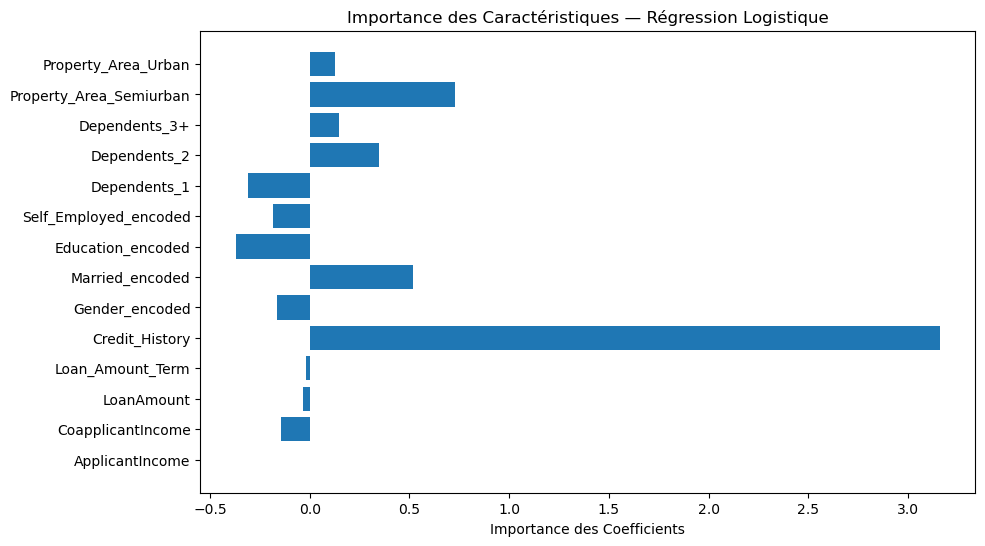

Intercept: -2.3043315472137667


In [35]:
# Récupérer les coefficients et l'intercept pour la régression logistique
feature_names = X_train.columns
coefficients = modele_lr.coef_[0]
intercept = modele_lr.intercept_[0]

# Visualiser les coefficients
plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefficients)
plt.xlabel("Importance des Coefficients")
plt.title("Importance des Caractéristiques — Régression Logistique")
plt.show()

# Afficher l'intercept
print("Intercept:", intercept)

Credit_History écrase tout le reste avec un coefficient d'environ 3.2, largement devant toutes les autres variables (qui tournent entre 0.4 et 0.8).
C'est donc le facteur décisif pour la régression logistique.

Ensuite, dans un ordre de grandeur très inférieur :

- Property_Area_Semiurban (0.7) et Married_encoded (0.5) : effet positif modéré, être en zone semi-urbaine ou marié pousse légèrement vers l'accord.
- Education_encoded (-0.4) : effet négatif (à vérifier comment cette variable est encodée (Graduate/Not Graduate), le signe dépend de l'ordre choisi par pd.Categorical.
- ApplicantIncome a un coefficient quasi nul (barre invisible). Cela est cohérent avec notre précédente observation, à savoir le revenu seul ne différencie pas significativement les dossiers.


### 6.2 L'arbre de décision

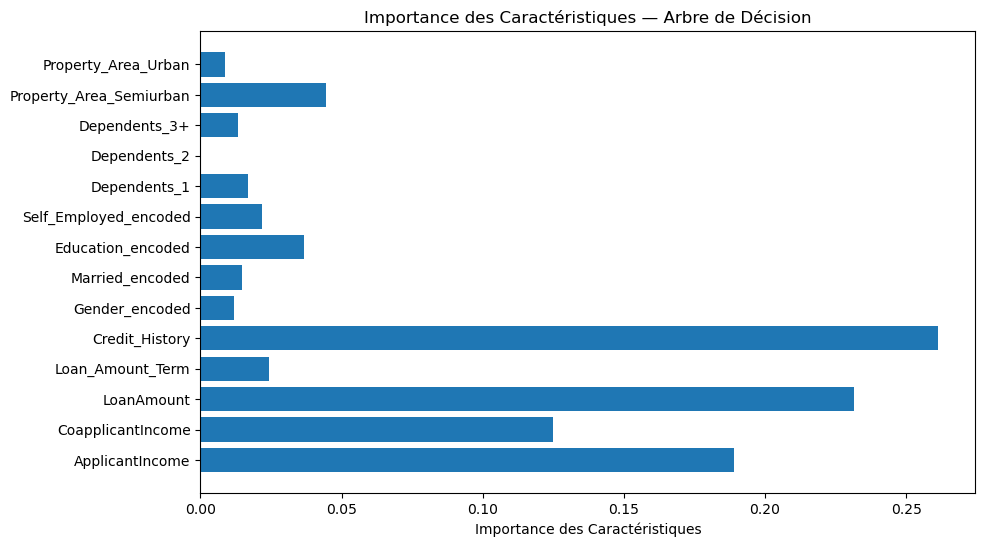

In [36]:
# Récupérer l'importance des caractéristiques pour l'arbre de décision
importances = modele_tree.feature_importances_
feature_names = X_train.columns

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance des Caractéristiques")
plt.title("Importance des Caractéristiques — Arbre de Décision")
plt.show()

Credit_History reste en tête (0.26), cohérent avec la régression logistique et l'EDA. Mais la suite diverge nettement du modèle précédent, et c'est un signal à interpréter avec prudence :

ApplicantIncome (0.18), LoanAmount (0.23), CoapplicantIncome (0.13) ressortent avec une importance forte alors que la régression logistique leur donnait un coefficient quasi nul, et que d'après notre EDA (boxplots section 2.5.D) on avait déjà conclu que ni le revenu ni le montant du prêt ne différenciaient significativement les dossiers acceptés/refusés.

### 6.2 Le Random Forest

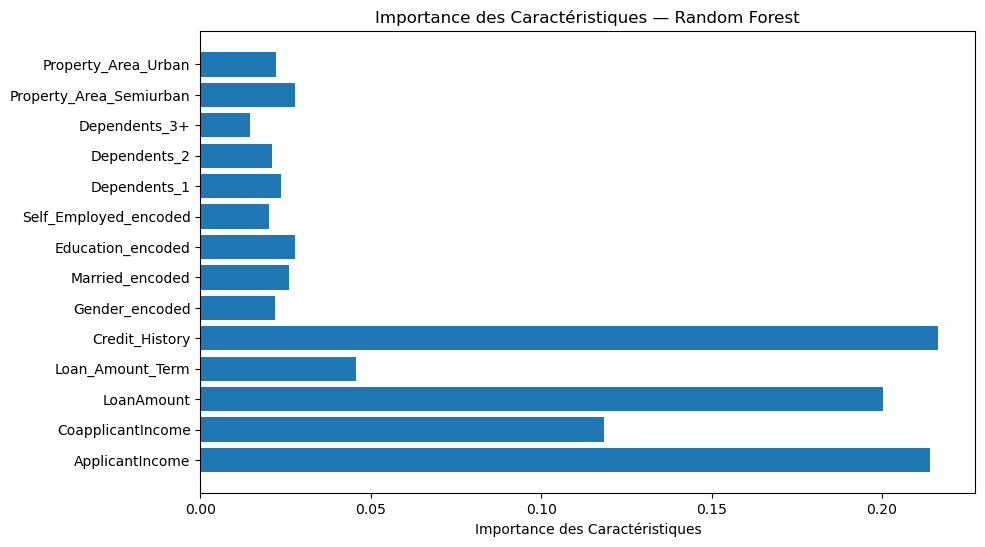

In [37]:
# Récupérer l'importance des caractéristiques pour le Random Forest
importances = modele_rf.feature_importances_
feature_names = X_train.columns

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance des Caractéristiques")
plt.title("Importance des Caractéristiques — Random Forest")
plt.show()

Credit_History reste en tête (0.21), cohérent avec la régression logistique et l'Arbre de Décision. C'est le facteur qui fait consensus entre les 3 modèles, confirmant sa place centrale déjà vue dans l'EDA.

Mais la suite reproduit le même schéma que l'Arbre de Décision seul, à savoir ApplicantIncome (0.23), LoanAmount (0.20), CoapplicantIncome (0.12) ressortent avec des poids élevés proches de ce qu'on avait vu sur l'arbre unique, alors que la régression logistique leur attribuait un coefficient quasi nul, et que l'EDA (boxplots) n'avait trouvé aucune différence significative sur ces variables entre dossiers acceptés/refusés.
Toutes les variables catégorielles (Married_encoded, Education_encoded, Property_Area, Dependents...) restent faibles comme sur l'arbre seul.

conclusion : les 3 modèles s'accordent sur Credit_History comme facteur numéro 1, mais divergent sur le reste — régression logistique vs modèles à base d'arbres ne "voient" pas le rôle des revenus/montant de la même façon. 

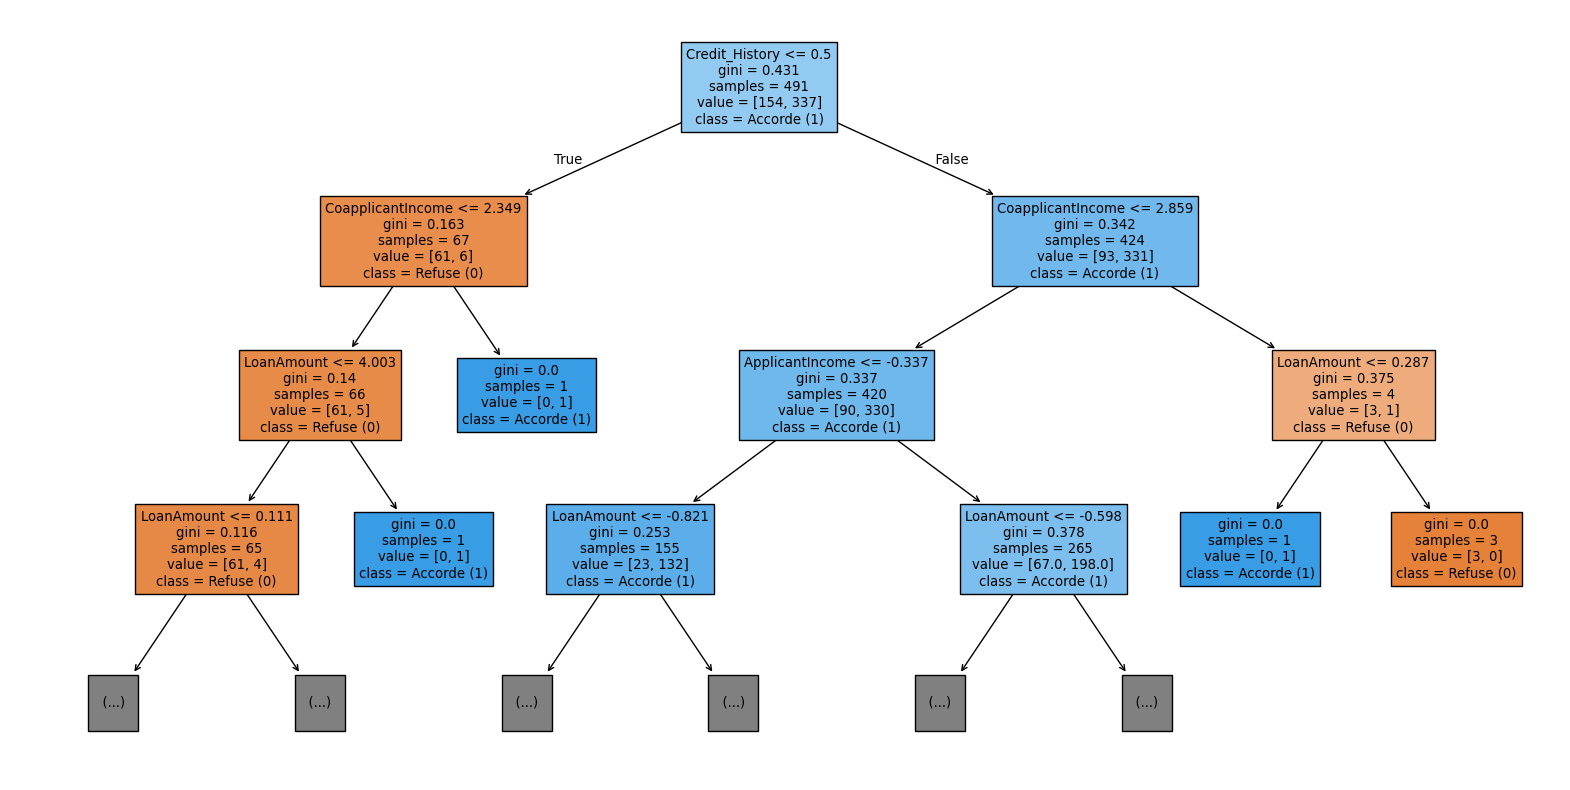

In [38]:
# Afficher la structure de l'arbre et observer les décisions prises à chaque niveau
plt.figure(figsize=(20, 10))
plot_tree(modele_tree, feature_names=X_train.columns, class_names=["Refuse (0)", "Accorde (1)"], filled=True, max_depth=3)
plt.show()

## 7) Evaluation des Modèles

### 7.1 Matrice de confusion

In [39]:
# Calcul et affichage de la matrice de confusion de chaque modèle

score_lr = metrics.confusion_matrix(y_test, y_pred_modele_lr)
print("\nRégression Logistique :\n", score_lr)

score_tree = metrics.confusion_matrix(y_test, y_pred_modele_tree)
print("\nArbre de Décision :\n", score_tree)

score_rf = metrics.confusion_matrix(y_test, y_pred_modele_rf)
print("\nRandom Forest :\n", score_rf)


Régression Logistique :
 [[22 16]
 [ 1 84]]

Arbre de Décision :
 [[24 14]
 [19 66]]

Random Forest :
 [[25 13]
 [ 7 78]]


| Modèle | VN | FP | FN | VP |
|---|---|---|---|---|
| Régression Logistique | 22 | 16 | 1 | 84 |
| Arbre de Décision | 24 | 14 | 19 | 66 |
| Random Forest | 25 | 13 | 7 | 78 |

Le Random Forest a le moins de Faux Positifs (13) — le cas grave dans notre contexte bancaire, où un vrai refus (0) est prédit à tort comme accord (1) — et c'est donc celui qui accorde le moins de prêts à des profils réellement à risque, le critère prioritaire. La Régression Logistique en a le plus (16) malgré une matrice qui a l'air "propre" (très peu de Faux Négatifs, seulement 1) — elle rate le plus de vrais refus. L'Arbre de Décision est entre les deux (14), mais avec le plus de Faux Négatifs (19, des bons dossiers refusés à tort).

### 7.2 Métriques d’Évaluation

#### A) Accuracy

In [40]:
score_lr = metrics.accuracy_score(y_test, y_pred_modele_lr)
print("\nRégression Logistique :\n", score_lr)

score_tree = metrics.accuracy_score(y_test, y_pred_modele_tree)
print("\nArbre de Décision :\n", score_tree)

score_rf = metrics.accuracy_score(y_test, y_pred_modele_rf)
print("\nRandom Forest :\n", score_rf)


Régression Logistique :
 0.8617886178861789

Arbre de Décision :
 0.7317073170731707

Random Forest :
 0.8373983739837398


La Régression Logistique a la meilleure accuracy globale (86.2%), mais c'est aussi celle qui accorde le plus de prêts à des profils réellement à risque (16 Faux Positifs). Ça s'explique simplement : elle est très bonne pour repérer les vrais refus quand elle les prédit (seulement 1 Faux Négatif), mais comme les accords sont majoritaires dans le dataset (68.7% de Y), elle gonfle son score global en étant "généreuse" sur les accords — elle prédit rarement le refus (seulement 23 fois sur 123 dossiers), donc elle rate beaucoup de vrais refus quand c'est la bonne réponse.

Remarque : toutes les erreurs de prédiction n'ont pas le même coût. L'évaluation de nos modèles devra donc prioriser la réduction des Faux Négatifs, plutôt que la seule accuracy globale. Ce résultat le prouve chiffres à l'appui.

#### B) Precision

In [41]:
precision_lr = metrics.precision_score(y_test, y_pred_modele_lr, pos_label=0)
precision_tree = metrics.precision_score(y_test, y_pred_modele_tree, pos_label=0)
precision_rf = metrics.precision_score(y_test, y_pred_modele_rf, pos_label=0)

print("Régression Logistique :", precision_lr)
print("Arbre de Décision :", precision_tree)
print("Random Forest :", precision_rf)

Régression Logistique : 0.9565217391304348
Arbre de Décision : 0.5581395348837209
Random Forest : 0.78125


La Régression Logistique est de loin la plus précise (95.7%) : quand elle prédit "refus", elle a presque toujours raison — seulement 1 Faux Négatif sur 23 prédictions de refus (voir matrice de confusion, section 7.1). L'Arbre de Décision est la moins précise (55.8%) : un peu plus d'une prédiction "refus" sur deux est en réalité un dossier qui aurait dû être accordé, cohérent avec ses 19 Faux Négatifs. Le Random Forest se situe entre les deux (78.1%).

#### C) Rappel (recall)

In [42]:
recall_lr = metrics.recall_score(y_test, y_pred_modele_lr, pos_label=0)
recall_tree = metrics.recall_score(y_test, y_pred_modele_tree, pos_label=0)
recall_rf = metrics.recall_score(y_test, y_pred_modele_rf, pos_label=0)

print("Régression Logistique :", recall_lr)
print("Arbre de Décision :", recall_tree)
print("Random Forest :", recall_rf)

Régression Logistique : 0.5789473684210527
Arbre de Décision : 0.631578947368421
Random Forest : 0.6578947368421053


Résultat qui confirme et inverse ce qu'on avait vu avec l'accuracy et la précision : la Régression Logistique, malgré sa meilleure accuracy (86.2%) et sa meilleure précision (95.7%), a le pire rappel (57.9%). Elle ne détecte qu'un peu plus d'un vrai refus sur deux. Le Random Forest, moins bon sur accuracy (83.7%) et précision (78.1%), est celui qui protège le mieux la banque sur le critère prioritaire, avec le meilleur rappel (65.8%). L'Arbre de Décision se situe entre les deux (63.2%).

Aucun des trois modèles ne dépasse les deux tiers de rappel — un point à souligner honnêtement : même le meilleur modèle laisse passer environ 1 vrai refus sur 3.

#### D) F1_score

In [43]:
f1_lr = metrics.f1_score(y_test, y_pred_modele_lr, pos_label=0)
f1_tree = metrics.f1_score(y_test, y_pred_modele_tree, pos_label=0)
f1_rf = metrics.f1_score(y_test, y_pred_modele_rf, pos_label=0)

print("Régression Logistique :", f1_lr)
print("Arbre de Décision :", f1_tree)
print("Random Forest :", f1_rf)

Régression Logistique : 0.7213114754098361
Arbre de Décision : 0.5925925925925926
Random Forest : 0.7142857142857143


Le F1_score remet la Régression Logistique en tête, grâce à sa précision exceptionnelle (95.7%) qui compense son rappel plus faible (57.9%) dans la moyenne harmonique — mais l'écart avec le Random Forest est minime (72.1% vs 71.4%, moins d'un point). L'Arbre de Décision, qui avait le meilleur rappel, se retrouve dernier au F1 à cause de sa précision nettement plus faible (55.8%).

Conclusion : le F1_score n'est pas le bon critère de départage ici, parce qu'il traite précision et rappel à parts égales, alors que le contexte bancaire du projet dit explicitement que le coût d'un Faux Négatif (rappel) prime sur celui d'un Faux Positif (précision). Sur ce critère prioritaire (rappel), c'est le Random Forest qui reste en tête (65.8%), pas la Régression Logistique.

#### D) Regroupement de toutes les métriques

In [44]:
# Regroupement de toutes les métriques pour comparaison
resultats = pd.DataFrame({
    "Modèle": ["Régression Logistique", "Arbre de Décision", "Random Forest"],
    "Accuracy": [
        metrics.accuracy_score(y_test, y_pred_modele_lr),
        metrics.accuracy_score(y_test, y_pred_modele_tree),
        metrics.accuracy_score(y_test, y_pred_modele_rf)
    ],
    "Précision": [precision_lr, precision_tree, precision_rf],
    "Rappel": [recall_lr, recall_tree, recall_rf],
    "F1-Score": [f1_lr, f1_tree, f1_rf]
})

# Tri par Rappel décroissant : le critère prioritaire vu le contexte métier
resultats.sort_values("Rappel", ascending=False)

,Modèle,Accuracy,Précision,Rappel,F1-Score
2,Random Forest,0.837398,0.781250,0.657895,0.714286
1,Arbre de Décision,0.731707,0.558140,0.631579,0.592593
0,Régression Logistique,0.861789,0.956522,0.578947,0.721311


In [45]:
# Vérification : que représentent y=0 et y=1 ?
verif = df_model[["Loan_Status"]].copy()
verif["y"] = y
print(verif.drop_duplicates())

  Loan_Status  y
0           Y  1
1           N  0


## 7) Analyse : vue d'ensemble

# Question 1 — Quelle est l'ampleur du risque de refus chez CrediTrust aujourd'hui ?

# KPI1 : Taux de refus global, répartition accordés/refusés

In [46]:
taux_refus_global = round((df_model["Loan_Status"] == "N").mean() * 100, 1)
nb_dossiers = len(df_model)
nb_accordes = int((df_model["Loan_Status"] == "Y").sum())
nb_refuses = int((df_model["Loan_Status"] == "N").sum())

print("Taux de refus global :", taux_refus_global, "%")
print("Nombre de dossiers :", nb_dossiers)
print("Accordés :", nb_accordes, "| Refusés :", nb_refuses)

Taux de refus global : 31.3 %
Nombre de dossiers : 614
Accordés : 422 | Refusés : 192


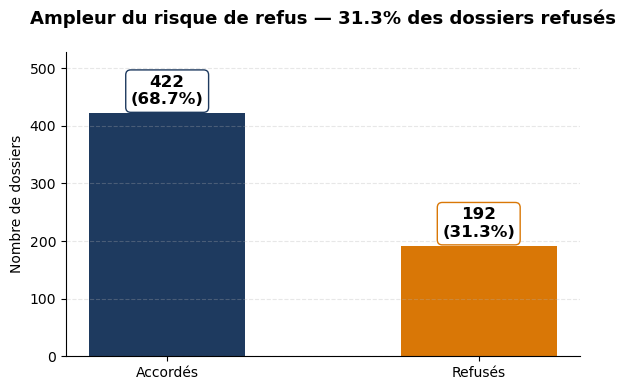

In [47]:
fig, ax = plt.subplots(figsize=(6,4))

valeurs = [nb_accordes, nb_refuses]
labels = ["Accordés", "Refusés"]
couleurs = ["#1E3A5F", "#D97706"]

barres = ax.bar(labels, valeurs, color=couleurs, width=0.5)

# Labels au-dessus de chaque barre (nombre + %)
pourcentages = [100 - taux_refus_global, taux_refus_global]
for barre, valeur, pct in zip(barres, valeurs, pourcentages):
    ax.text(barre.get_x() + barre.get_width()/2, barre.get_height() + 10,
             f"{valeur}\n({pct}%)", ha="center", va="bottom",
             fontsize=12, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=couleurs[valeurs.index(valeur)]))

ax.set_title(f"Ampleur du risque de refus — {taux_refus_global}% des dossiers refusés",
             fontsize=13, fontweight="bold", pad=20)
ax.set_ylabel("Nombre de dossiers")
ax.set_ylim(0, max(valeurs) * 1.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Sur 614 dossiers, 422 sont accordés (68,7 %) et 192 refusés (31,3 %).

#Près d'un dossier sur trois n'obtient pas son prêt — un taux de refus significatif qui sert de référence pour juger si un profil ou une zone est "plus à risque que la moyenne".

# Question 2 — L'historique de crédit doit-il rester prioritaire ?

# KPI2 : Taux de refus par Credit_History

In [48]:
refus_par_credit = df_model.groupby("Credit_History")["Loan_Status"].apply(lambda s: round((s == "N").mean() * 100, 1))
taux_refus_credit_mauvais = refus_par_credit[0.0]
taux_refus_credit_bon = refus_par_credit[1.0]

print("Taux de refus (mauvais historique) :", taux_refus_credit_mauvais, "%")
print("Taux de refus (bon historique) :", taux_refus_credit_bon, "%")

Taux de refus (mauvais historique) : 92.1 %
Taux de refus (bon historique) : 20.4 %


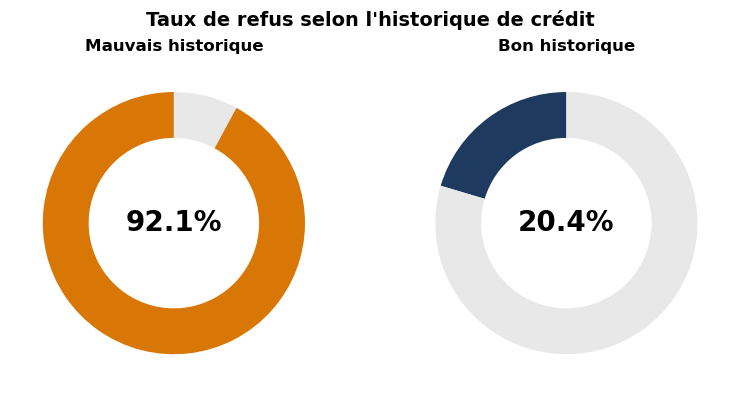

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(8,4))

groupes = [("Mauvais historique", taux_refus_credit_mauvais, "#D97706"),
           ("Bon historique", taux_refus_credit_bon, "#1E3A5F")]

for ax, (nom, taux, couleur) in zip(axes, groupes):
    ax.pie([taux, 100-taux], colors=[couleur, "#E8E8E8"], startangle=90,
           wedgeprops=dict(width=0.35))
    ax.text(0, 0, f"{taux}%", ha="center", va="center", fontsize=20, fontweight="bold")
    ax.set_title(nom, fontsize=12, fontweight="bold")

fig.suptitle("Taux de refus selon l'historique de crédit", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#  Écart massif entre les deux anneaux — 92,1 % de refus en cas de mauvais historique,
#contre seulement 20,4 % en cas de bon historique. Un écart de 71,7 points, de très loin le plus important de toute l'analyse. 

#Credit_History doit rester le critère décisif dans la politique d'octroi.

# Question 3 — Existe-t-il une inégalité géographique dans l'octroi de crédit ?

# KPI3 : Taux de refus par Property_Area

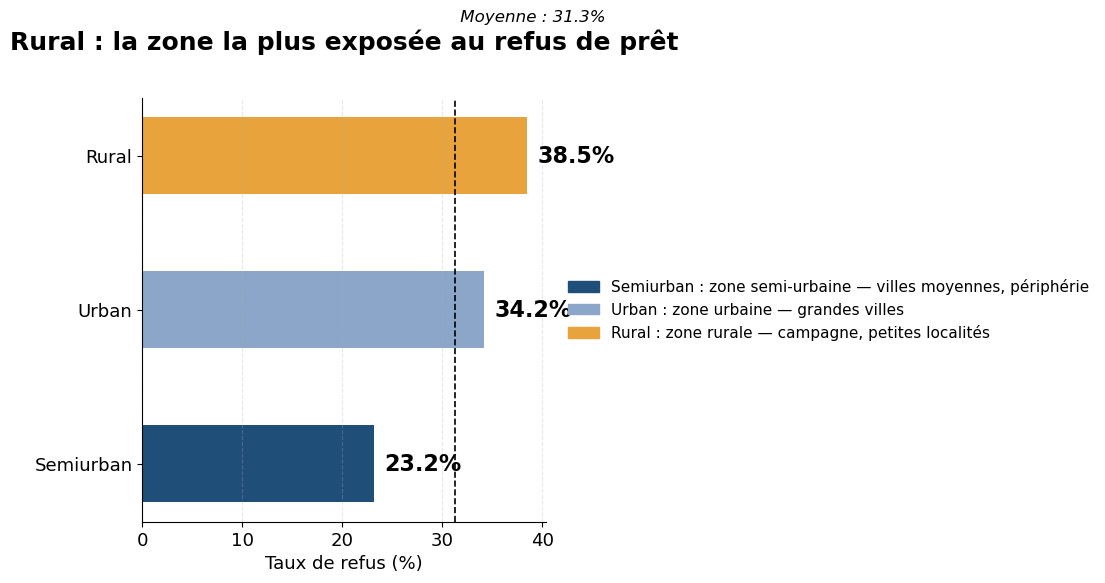

In [51]:
import matplotlib.patches as mpatches

refus_par_zone = df_model.groupby("Property_Area")["Loan_Status"].apply(lambda s: round((s == "N").mean() * 100, 1))
taux_refus_global = round((df_model["Loan_Status"] == "N").mean() * 100, 1)

fig, ax = plt.subplots(figsize=(11,6))

zones = refus_par_zone.sort_values()
couleurs_zones = ["#1F4E79" if v == zones.min() else "#E8A33D" if v == zones.max() else "#8CA6C9" for v in zones]

barres = ax.barh(zones.index, zones.values, color=couleurs_zones, height=0.5)

for barre, valeur in zip(barres, zones.values):
    ax.text(valeur + 1, barre.get_y() + barre.get_height()/2, f"{valeur}%",
             va="center", fontsize=16, fontweight="bold")

ax.axvline(taux_refus_global, color="black", linestyle="--", linewidth=1.2)
ax.text(taux_refus_global, len(zones) - 0.15, f" Moyenne : {taux_refus_global}%",
         fontsize=12, style="italic", va="bottom")

ax.set_title(f"{zones.idxmax()} : la zone la plus exposée au refus de prêt",
             fontsize=18, fontweight="bold", pad=35)
ax.set_xlabel("Taux de refus (%)", fontsize=13)
ax.tick_params(axis="both", labelsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

definitions = {
    "Rural": "zone rurale — campagne, petites localités",
    "Semiurban": "zone semi-urbaine — villes moyennes, périphérie",
    "Urban": "zone urbaine — grandes villes"
}
patches = [mpatches.Patch(color=couleur, label=f"{zone} : {definitions[zone]}")
           for zone, couleur in zip(zones.index, couleurs_zones)]
ax.legend(handles=patches, loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
#   La zone Rural est la plus exposée (38,5 % de refus), suivie d'Urban (34,2 %), tandis que Semiurban est la mieux servie (23,2 %). 
# Écart de 15,3 points entre la meilleure et la pire zone — un effet réel mais bien plus modéré que l'historique de crédit.
# Une inégalité d'accès au crédit selon la localisation, à interroger en recommandation.

# KPI 4 — Taux de refus par niveau d'éducation

#Question métier : Le niveau d'éducation influence-t-il la décision d'octroi, et est-ce un critère pertinent ou un biais à surveiller ?

In [ ]:
education_kpi = (
    df_model.groupby("Education")["Loan_Status"]
    .value_counts(normalize=True)
    .unstack()
)
education_kpi["TauxRefus%"] = round(education_kpi["N"] * 100, 1)
print(education_kpi[["N", "Y", "TauxRefus%"]])

NameError: name 'education_kpi' is not defined

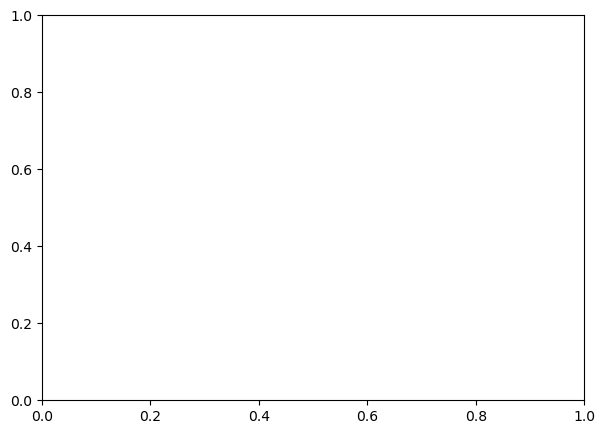

In [62]:
fig, ax = plt.subplots(figsize=(7,5))

categories = ["Graduate", "Not Graduate"]
valeurs = [education_kpi.loc["Graduate", "TauxRefus%"], education_kpi.loc["Not Graduate", "TauxRefus%"]]
couleurs = ["#1F4E79", "#E8A33D"]   # bleu marine (favorable) / ambre (à risque)

barres = ax.bar(categories, valeurs, color=couleurs, width=0.5)

for barre, valeur in zip(barres, valeurs):
    ax.text(barre.get_x() + barre.get_width()/2, valeur + 2, f"{valeur}%",
             ha="center", fontsize=15, fontweight="bold")

# Ligne de référence : moyenne globale
ax.axhline(taux_refus_global, color="black", linestyle="--", linewidth=1.2)
ax.text(1.55, taux_refus_global, f"Moyenne globale : {taux_refus_global}%",
         fontsize=10, style="italic", va="center")

# Facteur multiplicateur
facteur = round(valeurs[1] / valeurs[0], 1)
ax.annotate(f"x{facteur}", xy=(0.5, max(valeurs)*0.55), fontsize=18, fontweight="bold",
            color="#E8A33D", ha="center",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDF3E2", edgecolor="#E8A33D"))

ax.set_title("Un non-diplômé a 1,3x plus de risque d'être refusé qu'un diplômé",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Taux de refus (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Les non-diplômés sont refusés 1,3 fois plus souvent que les diplômés (38,8 % vs 29,2 %, écart de 9,6 points). 
# Un effet réel mais secondaire, très en dessous de celui de l'historique de crédit. 
# À mentionner avec prudence pour ne pas transformer ce critère en facteur discriminant.

# KPI5 : Tableau comparatif des 3 modèles (Accuracy, Précision, Rappel, F1, ROC-AUC)

In [ ]:
#Question 5 : Comparaison et choix du modèle de scoring Nous entraînons et évaluons les modèles (par exemple : Régression Logistique, Arbre de Décision, Random Forest) sur le jeu de test afin de constituer le tableau comparatif des performances. 

In [54]:
from sklearn import metrics
import pandas as pd

models = {
    "Régression Logistique": modele_lr,
    "Arbre de Décision": modele_tree,
    "Random Forest": modele_rf,
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # ROC-AUC : proba de la classe 1 suffit (symétrique)

    results.append({
        "Modèle": name,
        "Accuracy": round(metrics.accuracy_score(y_test, y_pred), 3),
        "Précision (N)": round(metrics.precision_score(y_test, y_pred, pos_label=0), 3),
        "Rappel (N)": round(metrics.recall_score(y_test, y_pred, pos_label=0), 3),
        "F1-Score (N)": round(metrics.f1_score(y_test, y_pred, pos_label=0), 3),
        "ROC-AUC": round(metrics.roc_auc_score(y_test, y_proba), 3),
    })

df_results = pd.DataFrame(results)
df_results

,Modèle,Accuracy,Précision (N),Rappel (N),F1-Score (N),ROC-AUC
0,Régression Logistique,0.862,0.957,0.579,0.721,0.852
1,Arbre de Décision,0.732,0.558,0.632,0.593,0.704
2,Random Forest,0.837,0.781,0.658,0.714,0.806


In [ ]:
#graphique KP5

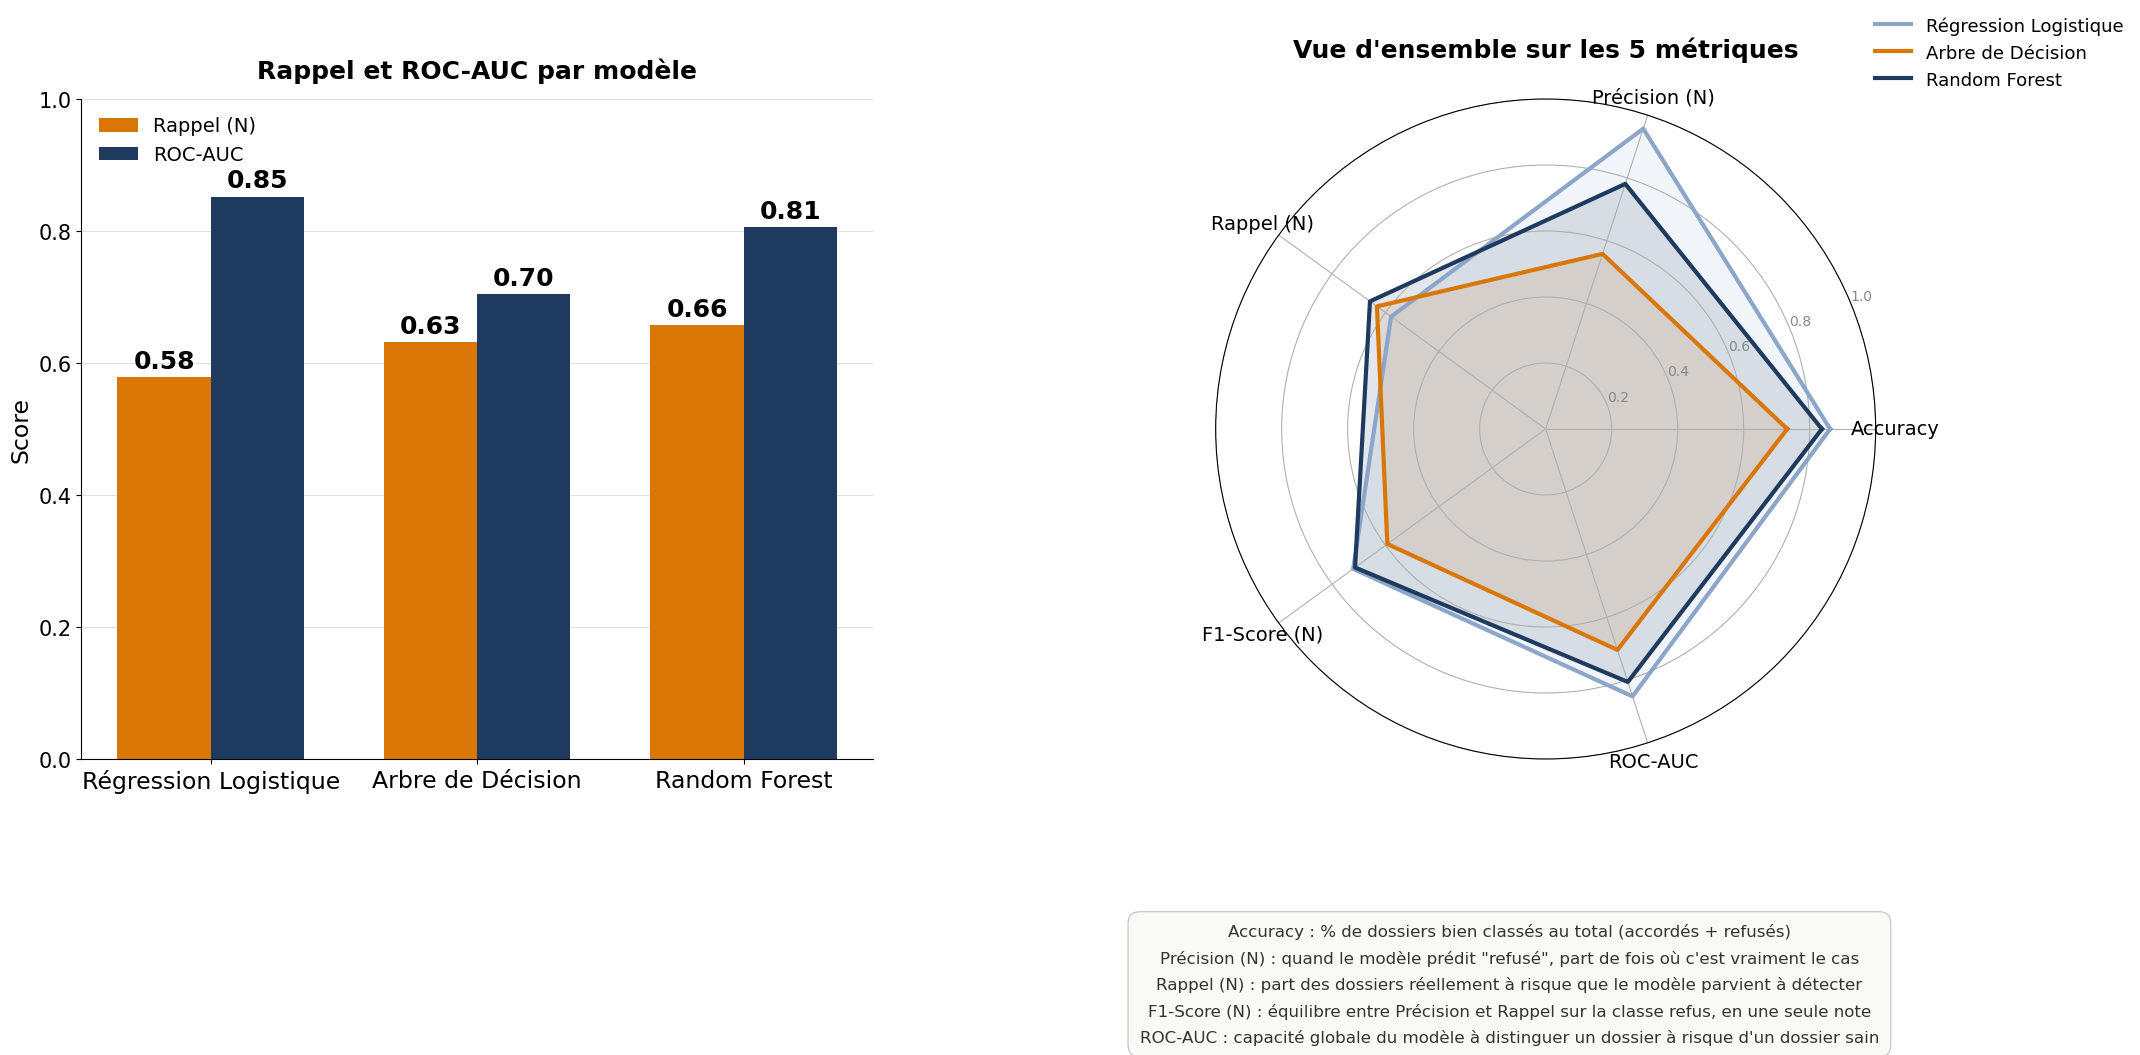

In [58]:
import matplotlib.pyplot as plt
import numpy as np

modeles = df_results["Modèle"].tolist()
rappel = df_results["Rappel (N)"].values
auc = df_results["ROC-AUC"].values
metrics_cols = ["Accuracy", "Précision (N)", "Rappel (N)", "F1-Score (N)", "ROC-AUC"]

fig = plt.figure(figsize=(24, 11))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, polar=True)

# --- Graphique 1 : barres Rappel / ROC-AUC ---
x = np.arange(len(modeles))
largeur = 0.35
b1 = ax1.bar(x - largeur/2, rappel, largeur, label="Rappel (N)", color="#D97706")
b2 = ax1.bar(x + largeur/2, auc, largeur, label="ROC-AUC", color="#1E3A5F")
ax1.bar_label(b1, fmt="%.2f", padding=3, fontsize=18, fontweight="bold")
ax1.bar_label(b2, fmt="%.2f", padding=3, fontsize=18, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(modeles, fontsize=17)
ax1.set_ylim(0, 1)
ax1.set_ylabel("Score", fontsize=17)
ax1.tick_params(axis="y", labelsize=15)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
ax1.grid(axis="y", color="#e1e0d9", linewidth=0.7, zorder=0)
ax1.set_axisbelow(True)
ax1.set_title("Rappel et ROC-AUC par modèle", fontsize=18, fontweight="bold", pad=15)
ax1.legend(loc="upper left", frameon=False, fontsize=14)

# --- Graphique 2 : radar des 5 métriques ---
angles = np.linspace(0, 2 * np.pi, len(metrics_cols), endpoint=False).tolist()
angles += angles[:1]
couleurs_modeles = {"Régression Logistique": "#8CA6C9", "Arbre de Décision": "#D97706", "Random Forest": "#1E3A5F"}

for _, row in df_results.iterrows():
    valeurs = row[metrics_cols].tolist()
    valeurs += valeurs[:1]
    ax2.plot(angles, valeurs, linewidth=3, label=row["Modèle"], color=couleurs_modeles[row["Modèle"]])
    ax2.fill(angles, valeurs, alpha=0.12, color=couleurs_modeles[row["Modèle"]])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics_cols, fontsize=14)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10, color="#888")
ax2.set_title("Vue d'ensemble sur les 5 métriques", fontsize=18, fontweight="bold", pad=30)
ax2.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), frameon=False, fontsize=13)

# --- Encadré d'explication, décalé vers la droite (zone vide sous le radar) ---
definitions_txt = (
    "Accuracy : % de dossiers bien classés au total (accordés + refusés)\n"
    "Précision (N) : quand le modèle prédit \"refusé\", part de fois où c'est vraiment le cas\n"
    "Rappel (N) : part des dossiers réellement à risque que le modèle parvient à détecter\n"
    "F1-Score (N) : équilibre entre Précision et Rappel sur la classe refus, en une seule note\n"
    "ROC-AUC : capacité globale du modèle à distinguer un dossier à risque d'un dossier sain"
)
fig.text(0.72, 0.02, definitions_txt, ha="center", va="bottom", fontsize=12, color="#333333",
          bbox=dict(boxstyle="round,pad=0.7", facecolor="#f9f9f7", edgecolor="#c3c2b7", linewidth=0.8), linespacing=1.8)

plt.subplots_adjust(bottom=0.28, wspace=0.35)
plt.show()

Ce graphique montre bien l'arbitrage au cœur du choix du modèle : la Régression Logistique domine sur l'Accuracy (0,86), la Précision (0,96) et même le ROC-AUC (0,85, le plus élevé des trois) — sa capacité globale à distinguer un dossier à risque d'un dossier sain est la meilleure. Mais elle s'effondre sur le Rappel (0,58, la barre orange la plus basse) — la métrique qui compte pourtant le plus ici. Le Random Forest offre le meilleur compromis : bon Rappel (0,66, le plus haut des trois), un ROC-AUC honorable (0,81), et reste solide sur les autres métriques (Accuracy 0,84, F1 0,71). C'est ce qui justifie de le retenir comme modèle final, malgré une Accuracy et un ROC-AUC légèrement inférieurs à la Régression Logistique — cohérent avec la priorité donnée à la détection des dossiers à risque plutôt qu'à la performance globale. Le ROC-AUC confirme aussi que l'Arbre de Décision seul (0,70) est le moins robuste des trois, malgré son bon Rappel (0,63) — signe qu'il capte bien les cas de risque sur ce jeu de test précis, mais de façon moins stable globalement.

# KPI6 : Rappel et Précision du modèle final (Random Forest), matrice de confusion

In [ ]:
# Quelles sont les limites du modèle retenu, à assumer honnêtement ? Rappel et Précision du modèle final, matrice de confusion

In [ ]:
from sklearn import metrics

modele_retenu = modele_rf
y_pred_retenu = modele_retenu.predict(X_test)

cm = metrics.confusion_matrix(y_test, y_pred_retenu)
tn, fp, fn, tp = cm.ravel()   # ordre original, correct pour alimenter le graphique ci-dessous

print(f"N bien refusé (refus justifié)          : {tn}")
print(f"N accordé à tort <- l'erreur la plus grave : {fp}")
print(f"Y refusé à tort (manque à gagner)        : {fn}")
print(f"Y bien accordé (accord légitime)         : {tp}")
print()
print("Rappel (N)   :", round(metrics.recall_score(y_test, y_pred_retenu, pos_label=0), 3))
print("Précision (N):", round(metrics.precision_score(y_test, y_pred_retenu, pos_label=0), 3))

In [ ]:
import matplotlib.pyplot as plt

total = tn + fp + fn + tp

# Bleu marine = décision correcte et favorable, gris = coût d'opportunité (refus injustifié),
# ambre = erreur grave (risque accordé à tort), bleu clair = décision correcte de protection
couleur_accord_ok = "#1F4E79"
couleur_refus_injuste = "#898781"
couleur_alerte = "#E8A33D"
couleur_refus_ok = "#2a78d6"

grille_couleurs = [
    [couleur_accord_ok, couleur_refus_injuste],
    [couleur_alerte, couleur_refus_ok],
]
grille_texte = [
    [f"Accord Légitime\n\n{tp} clients\n({tp/total*100:.1f}%)",
     f"Refus Injustifié\n(Manque à gagner)\n\n{fn} clients\n({fn/total*100:.1f}%)"],
    [f"⚠ Accordé à tort\n(Client à risque)\n\n{fp} clients\n({fp/total*100:.1f}%)",
     f"Refus Justifié\n(Risque évité)\n\n{tn} clients\n({tn/total*100:.1f}%)"],
]

fig, ax = plt.subplots(figsize=(7.5, 6))
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1, facecolor=grille_couleurs[i][j], edgecolor="white", linewidth=3))
        ax.text(j + 0.5, 1 - i + 0.5, grille_texte[i][j], ha="center", va="center",
                fontsize=10.5, fontweight="bold", color="white")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(["Prédit : Accordé", "Prédit : Refusé"], fontsize=10)
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(["Réalité : MAUVAIS PAYEUR (N)", "Réalité : BON PAYEUR (Y)"], fontsize=10)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
#  Sur 123 dossiers de test, le modèle se trompe dans les deux sens :

#13 clients à risque sont accordés à tort (10,6 %) — le vrai danger financier pour la banque, 
#ce sont les Faux Négatifs que l'énoncé demande de minimiser
#7 bons clients sont refusés injustement (5,7 %) — un manque à gagner commercial, moins grave mais réel

In [ ]:
# Export du tableau comparatif des modèles (Question 5)
df_results.to_csv("model_results.csv", index=False)

# Export de la matrice de confusion du modèle retenu (Question 6)
pd.DataFrame([{"tn": tn, "fp": fp, "fn": fn, "tp": tp}]).to_csv("confusion.csv", index=False)

print("Exports Question 5 et 6 terminés") 

In [ ]:
import shutil

destination = r"C:\Users\utilisateur\Downloads\salma s doc\machine learning\creditrust-scoring"

fichiers = ["modele_final.joblib", "kpis.csv", "graph_credit.csv", "graph_zone.csv", "graph_education.csv", "graph_repartition.csv", "model_results.csv", "confusion.csv"]

for f in fichiers:
    shutil.copy(f, destination)

print("Fichiers copiés dans", destination)

In [ ]:
kpis = {}
kpis["taux_refus_global"] = round((df_model["Loan_Status"] == "N").mean() * 100, 1)
kpis["nb_dossiers"] = len(df_model)
kpis["nb_accordes"] = int((df_model["Loan_Status"] == "Y").sum())
kpis["nb_refuses"] = int((df_model["Loan_Status"] == "N").sum())

refus_par_credit = df_model.groupby("Credit_History")["Loan_Status"].apply(lambda s: round((s == "N").mean() * 100, 1))
kpis["taux_refus_credit_mauvais"] = refus_par_credit[0.0]
kpis["taux_refus_credit_bon"] = refus_par_credit[1.0]

refus_par_zone = df_model.groupby("Property_Area")["Loan_Status"].apply(lambda s: round((s == "N").mean() * 100, 1))
kpis["zone_plus_risque"] = refus_par_zone.idxmax()
kpis["taux_refus_zone_plus_risque"] = refus_par_zone.max()

education_kpi = df_model.groupby("Education")["Loan_Status"].value_counts(normalize=True).unstack()
education_kpi["TauxRefus%"] = round(education_kpi["N"] * 100, 1)
kpis["taux_refus_graduate"] = education_kpi.loc["Graduate", "TauxRefus%"]
kpis["taux_refus_not_graduate"] = education_kpi.loc["Not Graduate", "TauxRefus%"]

print("kpis reconstruit :", kpis)

In [59]:
import joblib

joblib.dump(scaler, "scaler.joblib")
joblib.dump(list(X_train.columns), "colonnes_modele.joblib")
print("Colonnes du modèle :", list(X_train.columns))

Colonnes du modèle : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender_encoded', 'Married_encoded', 'Education_encoded', 'Self_Employed_encoded', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [60]:
import joblib
joblib.dump(scaler, "scaler.joblib")
joblib.dump(list(X_train.columns), "colonnes_modele.joblib")
print(list(X_train.columns))

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender_encoded', 'Married_encoded', 'Education_encoded', 'Self_Employed_encoded', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [61]:
import shutil
destination = r"C:\Users\utilisateur\Downloads\salma s doc\machine learning\creditrust-scoring"
shutil.copy("scaler.joblib", destination)
shutil.copy("colonnes_modele.joblib", destination)
print("Copiés")

Copiés


Sélection du modèle final

Modèle retenu : le Random Forest, sur la base du rappel (65.8%), le critère prioritaire défini dans le contexte métier du projet (minimiser les prêts accordés à tort à des profils à risque, plutôt que maximiser l'accuracy globale).

Justification :

Sur les 3 modèles, aucun n'atteint un rappel très élevé (tous sous 66%), mais le Random Forest est celui qui détecte le mieux les vrais refus (65.8%, contre 63.2% pour l'Arbre de Décision et seulement 57.9% pour la Régression Logistique).
Ce choix va à l'encontre de ce que suggéreraient l'accuracy (86.2% pour la Régression Logistique, la meilleure) ou même le F1-Score (72.1% pour la Régression Logistique, également en tête) — et c'est la démonstration chiffrée annoncée dès l'introduction du notebook : optimiser l'accuracy globale ou le F1 (qui traite précision et rappel à parts égales) aurait conduit à retenir le modèle qui protège le moins bien la banque sur le critère qui compte réellement ici.
Le compromis assumé : ce choix coûte en précision (78.1% contre 95.7% pour la Régression Logistique) — davantage de bons dossiers refusés à tort, un coût réel mais secondaire par rapport à celui d'un prêt à risque accordé.

Limite à mentionner honnêtement : un rappel de 65.8% reste imparfait en absolu — environ 1 vrai refus sur 3 échappe encore au modèle. Pistes d'amélioration à envisager pour aller plus loin (à mentionner en ouverture) : class_weight='balanced' pour forcer les modèles à mieux traiter la classe minoritaire (refus, 31.3% du dataset), ou ajuster le seuil de décision (predict_proba + seuil personnalisé au lieu de 0.5 par défaut) plutôt que de changer de modèle.

Lien avec l'interprétation (section 6) : les 3 modèles s'accordent sur Credit_History comme facteur numéro 1 — cohérent avec l'EDA (écart de 71.7 points). L'Arbre de Décision et le Random Forest captent en plus un signal sur les variables de revenu/montant que la régression logistique linéaire ne voit pas, ce qui peut expliquer en partie leur meilleur rappel.

Écrivez un message…

## 8) Recommandations

Politique d'octroi :

- Garder l'historique de crédit comme critère central de la politique d'octroi — son poids écrase largement tous les autres facteurs (71,7 points d'écart, confirmé par l'EDA et les trois modèles).
- Investiguer l'écart géographique entre zones rurales et semi-urbaines (15,3 points) — pour vérifier s'il reflète un vrai risque économique ou un biais d'accès au crédit à corriger.
- Utiliser le niveau d'éducation avec prudence (effet réel mais modéré, 9,6 points) — pour ne pas en faire un critère discriminant.

Déploiement technique et limites: 

- Déployer le modèle retenu (Random Forest, Rappel de 65,8 %) comme un outil d'aide à la décision, pas un remplacement du conseiller — il laisse encore passer environ 1 dossier à risque sur 3.
- Limite structurelle : l'échantillon actuel (614 dossiers) reste réduit pour garantir robustesse statistique et équité entre profils dans un déploiement à grande échelle — la collecte de données supplémentaires est prioritaire.